### Student Information
Name:Javio Felix (方浩偉)

Student ID: R14K47026

GitHub ID: Irl-Felix

---

### Instructions

### First Phase Submission

1. First: do the **take home** exercises in the [DM2025-Lab1-Master](https://github.com/leoson-wu/DM2025-Lab1-Exercise/blob/main/DM2025-Lab1-Master.ipynb) that considered as **phase 1 (from exercise 1 to exercise 15)**. You can answer in the master file. __This part is worth 10% of your grade.__


2. Second: follow the same process from the [DM2025-Lab1-Master](https://github.com/leoson-wu/DM2025-Lab1-Exercise/blob/main/DM2025-Lab1-Master.ipynb) on **the new dataset** up **until phase 1**. You can skip some exercises if you think some steps are not necessary. However main exercises should be completed. You don't need to explain all details as we did (some **minimal comments** explaining your code are useful though).  __This part is worth 15% of your grade.__
    -  Use [the new dataset](https://github.com/leoson-wu/DM2025-Lab1-Exercise/blob/main/newdataset/Reddit-stock-sentiment.csv). The dataset contains a 16 columns including 'text' and 'label', with the sentiment labels being: 1.0 is positive, 0.0 is neutral and -1.0 is negative. You can simplify the dataset and use only the columns that you think are necessary. 
    
    - You are allowed to use and modify the `helper` functions in the folder of the first lab session (notice they may need modification) or create your own.
    - Use this file to complete the homework from the second part. Make sure the code can be run from the beginning till the end and has all the needed output.


3. Third: please attempt the following tasks on **the new dataset**. __This part is worth 10% of your grade.__
    - Generate meaningful **new data visualizations**. Refer to online resources and the Data Mining textbook for inspiration and ideas. 
    


4. Fourth: It's hard for us to follow if your code is messy, so please **tidy up your notebook** and **add minimal comments where needed**. __This part is worth 5% of your grade.__

You can submit your homework following these guidelines: [DM2025-Lab1-announcement](https://github.com/leoson-wu/DM2025-Lab1-Announcement/blob/main/README.md). Make sure to commit and save your changes to your repository __BEFORE the deadline (September 28th 11:59 pm, Sunday)__. 

### Second Phase Submission 

**You can keep the answer for phase 1 for easier running and update the phase 2 on the same page.**

1. First: Continue doing the **take home** exercises in the [DM2025-Lab1-Master](https://github.com/leoson-wu/DM2025-Lab1-Exercise/blob/main/DM2025-Lab1-Master.ipynb) for **phase 2, starting from Finding frequent patterns**. Use the same master(.ipynb) file. Answer from phase 1 will not be considered at this stage. You can answer in the master file. __This part is worth 10% of your grade.__


2. Second: Continue from first phase and do the same process from the [DM2025-Lab1-Master](https://github.com/leoson-wu/DM2025-Lab1-Exercise/blob/main/DM2025-Lab1-Master.ipynb) on **the new dataset** for phase 2, starting from Finding frequent pattern. You can skip some exercises if you think some steps are not necessary. However main exercises should be completed. You don't need to explain all details as we did (some **minimal comments** explaining your code are useful though).  __This part is worth 15% of your grade.__
    - Continue using this file to complete the homework from the second part. Make sure the code can be run from the beginning till the end and has all the needed output. Use the same new dataset as in phase 1.
    
    - You are allowed to use and modify the `helper` functions in the folder of the first lab session (notice they may need modification) or create your own.

3. Third: please attempt the following tasks on **the new dataset**. __This part is worth 20% of your grade.__
    - Use this file to answer.
    - Generate **TF-IDF features** from the tokens of each text. This will generating a document matrix, however, the weights will be computed differently (using the TF-IDF value of each word per document as opposed to the word frequency).  Refer to this Scikit-learn [guide](http://scikit-learn.org/stable/modules/generated/sklearn.feature_extraction.text.TfidfVectorizer.html) .
    - Implement a simple **Naive Bayes classifier** that automatically classifies the records into their categories. Use both the TF-IDF features and word frequency features to build two seperate classifiers. Note that for the TF-IDF features you might need to use other type of NB classifier different than the one in the Master Notebook. Comment on the differences and when using augmentation with feature pattern.  Refer to this [article](https://hub.packtpub.com/implementing-3-naive-bayes-classifiers-in-scikit-learn/).


4. Fourth: In the lab, we applied each step really quickly just to illustrate how to work with your dataset. There are somethings that are not ideal or the most efficient/meaningful. Each dataset can be handled differently as well. What are those inefficent parts you noticed? How can you improve the Data preprocessing for these specific datasets? __This part is worth 10% of your grade.__


5. Fifth: It's hard for us to follow if your code is messy, so please **tidy up your notebook** and **add minimal comments where needed**. __This part is worth 5% of your grade.__


You can submit your homework following these guidelines: [DM2025-Lab1-announcement](https://github.com/leoson-wu/DM2025-Lab1-Announcement/blob/main/README.md). Make sure to commit and save your changes to your repository __BEFORE the deadline (October 19th 11:59 pm, Sunday)__. 

# Phase 1 - Begin Assignment Here

### Data Source,Data Preparation(Just loaded from CSV)

In [1]:
#Necessary Imports
import pandas as pd
import helpers.data_mining_helpers as dmh
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import CountVectorizer
from wordcloud import WordCloud

import random
import numpy as np
import seaborn as sns
!pip install wordcloud
%matplotlib inline

import nltk
nltk.download("punkt")
nltk.download("punkt_tab")

[nltk_data] Downloading package punkt to /Users/bitbandit/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     /Users/bitbandit/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [2]:
#Loading the csv File into a DataFrame.
df = pd.read_csv("newdataset/Reddit-stock-sentiment.csv")

##### Getting Familiar with the Data - a

In [3]:
#Shape & column overview
print("Shape:", df.shape)
print("Columns:", df.columns.tolist())

Shape: (847, 16)
Columns: ['type', 'datetime', 'post_id', 'subreddit', 'title', 'author', 'url', 'upvotes', 'downvotes', 'upvote_ratio', 'text', 'subjectivity', 'polarity', 'sentiment', 'entities', 'label']


In [4]:
#Check the first 5 of the whole dataframe
df.head()

,type,datetime,post_id,subreddit,title,author,url,upvotes,downvotes,upvote_ratio,text,subjectivity,polarity,sentiment,entities,label
0,comment,2025-04-11 17:29:56,mmli62w,wallstreetbets,Retardation is on the menu boys! WSB is so back,StickyTip420,https://i.redd.it/0yq2ftren8ue1.jpeg,0,NaN,NaN,Calls on retards,1.000000,-0.900000,-1.0,[],-1.0
1,comment,2025-04-12 1:12:19,mmnu7v9,wallstreetbets,Retail giant TARGET has now declined for 10 co...,Comfortable-Dog-8437,https://i.redd.it/7tl6puv9waue1.jpeg,-15,NaN,NaN,Stunt as in like why did they even make a big ...,0.177778,0.083333,1.0,"['Stunt', 'company', 'deal', 'place']",0.0
2,comment,2025-04-10 15:09:41,mmeevio,StockMarket,How do you feel about a sitting president maki...,Btankersly66,https://apnews.com/article/trump-truth-social-...,1,NaN,NaN,Seeing lots of red in the ticker.,0.000000,0.000000,0.0,['ticker'],0.0
3,post,2023-08-30 17:12:55,165kllm,stockstobuytoday,Who knows more? $VMAR,emiljenfn,https://www.reddit.com/r/stockstobuytoday/comm...,30,0.0,0.98,Vision Marine Technologies Inc. is rewriting t...,0.646970,0.216383,1.0,"['watercraft', 'skill', 'power', ']', 'feat', ...",1.0
4,comment,2025-04-11 14:48:05,mmkl6bw,StockMarket,The Trump administration is begging Xi Jinping...,Just-Big6411,https://edition.cnn.com/2025/04/10/politics/tr...,1,NaN,NaN,He didn’t say thank you.,0.000000,0.000000,0.0,[],-1.0


In [5]:
# Data types & info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 847 entries, 0 to 846
Data columns (total 16 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   type          847 non-null    object 
 1   datetime      847 non-null    object 
 2   post_id       847 non-null    object 
 3   subreddit     847 non-null    object 
 4   title         847 non-null    object 
 5   author        847 non-null    object 
 6   url           847 non-null    object 
 7   upvotes       847 non-null    int64  
 8   downvotes     64 non-null     float64
 9   upvote_ratio  64 non-null     float64
 10  text          847 non-null    object 
 11  subjectivity  847 non-null    float64
 12  polarity      847 non-null    float64
 13  sentiment     847 non-null    float64
 14  entities      847 non-null    object 
 15  label         847 non-null    float64
dtypes: float64(6), int64(1), object(9)
memory usage: 106.0+ KB


In [6]:
# Unique values in type and subreddit
print("Type counts:\n", df["type"].value_counts(), "\n")
print("Subreddit counts:\n", df["subreddit"].value_counts(), "\n")

# Sentiment and label distributions
print("Sentiment counts:\n", df["sentiment"].value_counts(), "\n")
print("Label counts:\n", df["label"].value_counts(), "\n")

# Text length overview
df["text_len"] = df["text"].str.len()

Type counts:
 type
comment    783
post        64
Name: count, dtype: int64 

Subreddit counts:
 subreddit
stocks              274
StockMarket         250
stockstobuytoday    174
wallstreetbets      149
Name: count, dtype: int64 

Sentiment counts:
 sentiment
 0.0    331
 1.0    319
-1.0    197
Name: count, dtype: int64 

Label counts:
 label
 0.0    423
-1.0    315
 1.0    109
Name: count, dtype: int64 



### Data Transformation

In [7]:
#Most useful for the analysis
X = df[['text','subreddit', 'label']]

##### Familiarizing yourself with the Data

In [8]:
# Using Head
X.head(5)

,text,subreddit,label
0,Calls on retards,wallstreetbets,-1.0
1,Stunt as in like why did they even make a big ...,wallstreetbets,0.0
2,Seeing lots of red in the ticker.,StockMarket,0.0
3,Vision Marine Technologies Inc. is rewriting t...,stockstobuytoday,1.0
4,He didn’t say thank you.,StockMarket,-1.0


In [9]:
#Checking the differnt amount of subreddits
df['subreddit'].nunique()

4

In [10]:
#Querying the Last few records
X[-5:]

,text,subreddit,label
842,Invest now it is going to shoot up tomorrow,stockstobuytoday,1.0
843,Where can I read this?,StockMarket,0.0
844,"Upgrades, Downgrades\n\n [Stock Analyst Recomm...",stockstobuytoday,0.0
845,i sold my puts so i expect cheeto to declare w...,wallstreetbets,-1.0
846,![img](emote|t5_2th52|31224),wallstreetbets,0.0


In [11]:
#Query using isin()
X[X['label'].isin([0.0,1.0])]

,text,subreddit,label
1,Stunt as in like why did they even make a big ...,wallstreetbets,0.0
2,Seeing lots of red in the ticker.,StockMarket,0.0
3,Vision Marine Technologies Inc. is rewriting t...,stockstobuytoday,1.0
5,"Hoping to ejaculate in wet warm puss tonight, ...",wallstreetbets,0.0
7,Confirmed not a trap. Its been like this for p...,wallstreetbets,0.0
...,...,...,...
841,So countries “begging to stop the tariffs” and...,StockMarket,1.0
842,Invest now it is going to shoot up tomorrow,stockstobuytoday,1.0
843,Where can I read this?,StockMarket,0.0
844,"Upgrades, Downgrades\n\n [Stock Analyst Recomm...",stockstobuytoday,0.0


In [12]:
#Check for null values
X.isnull().sum()

text         0
subreddit    0
label        0
dtype: int64

In [13]:
X.isnull().apply(lambda x: dmh.check_missing_values(x))

,text,subreddit,label
0,The amoung of missing records is:,The amoung of missing records is:,The amoung of missing records is:
1,0,0,0


In [14]:
#Check missing values
X.isna().sum()

text         0
subreddit    0
label        0
dtype: int64

In [15]:
#Check for duplicates and also remove duplicates
X = X.copy()
# Check how many duplicates
print("Number of duplicate rows before:", X.duplicated().sum())

# Drop duplicates safely
X = X.drop_duplicates(keep=False)

# Verify again
print("Number of duplicate rows after:", X.duplicated().sum())

Number of duplicate rows before: 23
Number of duplicate rows after: 0


In [16]:
#Checking the length
len(X)

813

###  Data Preprocessing

In [17]:
X_sample = X.sample(n=300) #random state

In [18]:
X_sample[0:10]

,text,subreddit,label
245,Let him take it all and much more. I want his ...,StockMarket,-1.0
801,No. PERIOD.,stocks,0.0
345,"Sun Tzu wrote in The Art of War: “*In war, the...",StockMarket,0.0
17,"Exactly this. Trump will blink first because, ...",stocks,-1.0
738,Plain spaghetti not so bad actually,wallstreetbets,0.0
522,Why would I support this idiotic administratio...,stocks,-1.0
622,Xi is leader for life of a totalitarian regime...,StockMarket,-1.0
112,"nice, good info, good post.",stockstobuytoday,1.0
376,Remember when Powell was asked this question a...,stocks,0.0
700,Donno why you’re getting downvoted. You’re not...,wallstreetbets,1.0


In [19]:
# A) Fasdt Look at Data
print("\n--- X ---")
print(X.head())
print(X.tail())
print(X.sample(5))
print()
print("\n--- X_sample ---")
print(X_sample.head())
print(X_sample.tail())
print(X_sample.sample(5))


--- X ---
                                                text         subreddit  label
0                                   Calls on retards    wallstreetbets   -1.0
1  Stunt as in like why did they even make a big ...    wallstreetbets    0.0
2                  Seeing lots of red in the ticker.       StockMarket    0.0
3  Vision Marine Technologies Inc. is rewriting t...  stockstobuytoday    1.0
4                           He didn’t say thank you.       StockMarket   -1.0
                                                  text         subreddit  \
841  So countries “begging to stop the tariffs” and...       StockMarket   
842        Invest now it is going to shoot up tomorrow  stockstobuytoday   
843                             Where can I read this?       StockMarket   
845  i sold my puts so i expect cheeto to declare w...    wallstreetbets   
846                       ![img](emote|t5_2th52|31224)    wallstreetbets   

     label  
841    1.0  
842    1.0  
843    0.0  
845   -1.0  

In [20]:
# D) Basic Statistics
print("\n--- X ---")
print(X.describe())
print(X.describe(include='object'))

print("\n--- X_sample ---")
print(X_sample.describe())
print(X_sample.describe(include='object'))


--- X ---
            label
count  813.000000
mean    -0.255843
std      0.673920
min     -1.000000
25%     -1.000000
50%      0.000000
75%      0.000000
max      1.000000
                    text subreddit
count                813       813
unique               813         4
top     Calls on retards    stocks
freq                   1       272

--- X_sample ---
            label
count  300.000000
mean    -0.250000
std      0.660014
min     -1.000000
25%     -1.000000
50%      0.000000
75%      0.000000
max      1.000000
                                                     text    subreddit
count                                                 300          300
unique                                                300            4
top     Let him take it all and much more. I want his ...  StockMarket
freq                                                    1           96


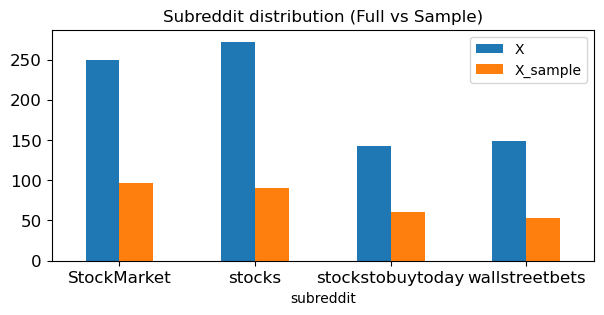

In [21]:
# Count subreddit distribution
x_counts = X['subreddit'].value_counts()
x_sample_counts = X_sample['subreddit'].value_counts()


X_and_Xsamp = pd.DataFrame({
    "X": x_counts,
    "X_sample": x_sample_counts
})

# Plot
X_and_Xsamp.plot(kind="bar", figsize=(7,3), rot=0, fontsize=12)
plt.title("Subreddit distribution (Full vs Sample)")
plt.ylim(0, max(x_counts.max(), x_sample_counts.max()) + 15)
plt.show()

In [22]:
X['unigrams'] = X['text'].apply(lambda x: dmh.tokenize_text(x))
X[0:4]["unigrams"]

0                                 [Calls, on, retards]
1    [Stunt, as, in, like, why, did, they, even, ma...
2          [Seeing, lots, of, red, in, the, ticker, .]
3    [Vision, Marine, Technologies, Inc., is, rewri...
Name: unigrams, dtype: object

In [23]:
list(X[0:2]['unigrams'])

[['Calls', 'on', 'retards'],
 ['Stunt',
  'as',
  'in',
  'like',
  'why',
  'did',
  'they',
  'even',
  'make',
  'a',
  'big',
  'deal',
  'about',
  'starting',
  'it',
  'in',
  'the',
  'first',
  'place',
  '?',
  'No',
  'company',
  'should',
  'ever',
  'talk',
  'about',
  'politics',
  'ever',
  '.']]

In [24]:
#Assign to text variablee
text_data = X["text"].fillna("").astype(str)

In [44]:
# tokenize text into words,  and so on ... ...
count_vect = CountVectorizer(stop_words='english')
analyze = count_vect.build_analyzer()

# Learn vocab + transform text
X_counts = count_vect.fit_transform(text_data)

# Vocabulary
vocab = count_vect.get_feature_names_out()

# Term frequencies (sum over all docs)
counts = np.asarray(X_counts.sum(axis=0)).ravel()

In [45]:
count_vect.get_feature_names_out()[555]

'bought'

In [30]:
analyze(X['text'].iloc[1])

['stunt',
 'like',
 'did',
 'make',
 'big',
 'deal',
 'starting',
 'place',
 'company',
 'talk',
 'politics']

In [31]:
# we convert from sparse array to normal array
X_counts[0:5, 0:100].toarray()

array([[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0,

In [32]:
mask = X_counts[4].indices
print("Indices with 1s:", mask)
print("Words:", [count_vect.get_feature_names_out()[i] for i in mask])

Indices with 1s: [1105 3159 3627]
Words: ['didn', 'say', 'thank']


doc_idx: [654, 114, 25, 759, 281, 250, 228, 142, 754, 104, 692, 758, 558, 89, 604]
term_idx: [2064, 3739, 2173, 2284, 743, 3636, 2648, 1636, 1641, 2394, 3593, 2263, 3664, 3926, 1160]


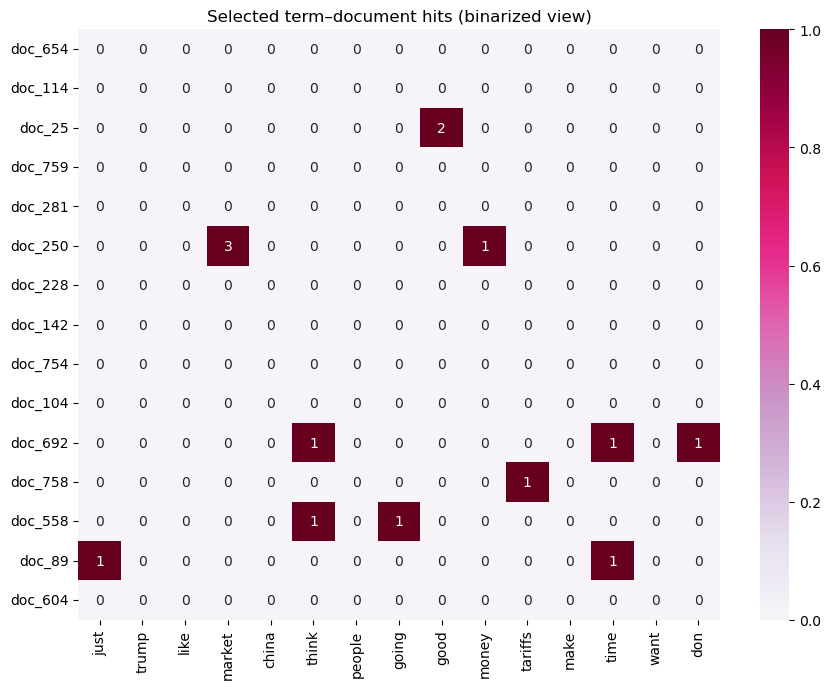

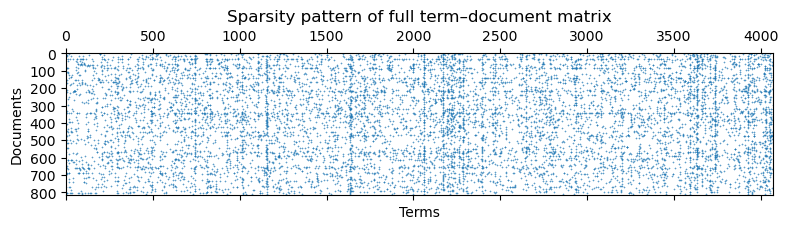

In [33]:
# --- pick 15 documents ---
random.seed(42)
n_docs = X_counts.shape[0]
doc_idx = random.sample(range(n_docs), 15)

# --- pick 15 terms with total frequency > 50 ---
term_frequencies = np.asarray(X_counts.sum(axis=0)).ravel()
term_idx = [i for i, f in enumerate(term_frequencies) if f > 50][:15]
if len(term_idx) < 15:
    #take top-15 by frequency
    term_idx = np.argsort(-term_frequencies)[:15].tolist()

print("doc_idx:", doc_idx)
print("term_idx:", term_idx)

# --- i making the labels here ---
feature_names = count_vect.get_feature_names_out()
plot_x = [f"{t}" for t in feature_names[term_idx]]
plot_y = [f"doc_{i}" for i in doc_idx]

# --- slice the sparse matrix and convert to dense for plotting ---
plot_z = X_counts[np.ix_(doc_idx, term_idx)].toarray()

df_todraw = pd.DataFrame(plot_z, columns=plot_x, index=plot_y)
plt.subplots(figsize=(9, 7))
ax = sns.heatmap(df_todraw, cmap="PuRd", vmin=0, vmax=1, annot=True)
plt.title("Selected term–document hits (binarized view)")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8,6))
plt.spy(X_counts, markersize=0.2)
plt.title("Sparsity pattern of full term–document matrix")
plt.xlabel("Terms")
plt.ylabel("Documents")
plt.tight_layout()
plt.show()

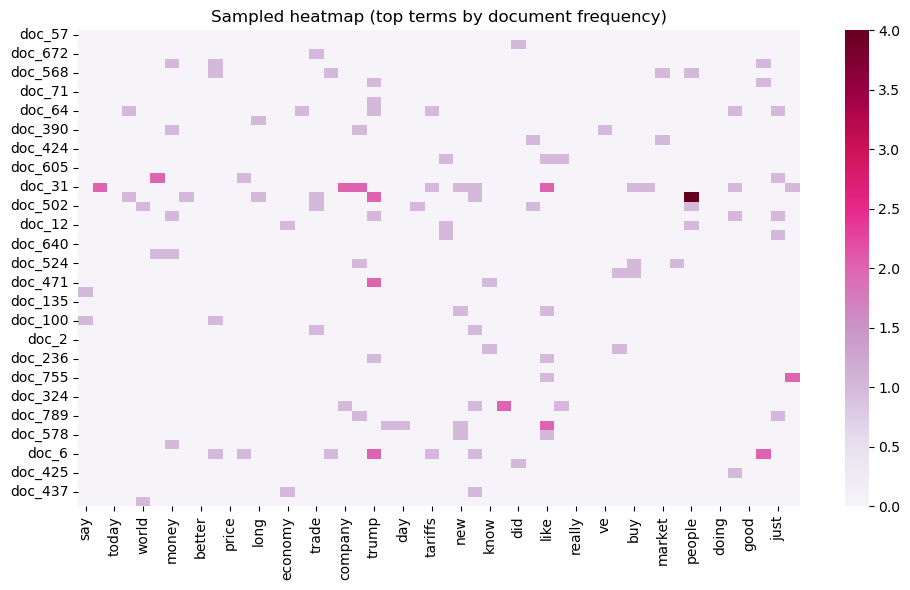

In [34]:
rng = np.random.default_rng(0)

n_docs  = 50
n_terms = 50

doc_idx  = rng.choice(X_counts.shape[0], size=n_docs, replace=False)

df_counts = np.asarray((X_counts > 0).sum(axis=0)).ravel()
term_idx = np.argpartition(df_counts, -n_terms)[-n_terms:]

sub = X_counts[doc_idx][:, term_idx].toarray()

feature_names = count_vect.get_feature_names_out()
cols = [feature_names[i] for i in term_idx]
rows = [f"doc_{i}" for i in doc_idx]

plt.figure(figsize=(10,6))
ax = sns.heatmap(pd.DataFrame(sub, index=rows, columns=cols),
                 cmap="PuRd", vmin=0, vmax=sub.max() or 1, annot=False)
ax.set_title("Sampled heatmap (top terms by document frequency)")
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [35]:
# Frequency table
freq_df = pd.DataFrame({"word": vocab, "count": counts}).sort_values("count", ascending=False).reset_index(drop=True)

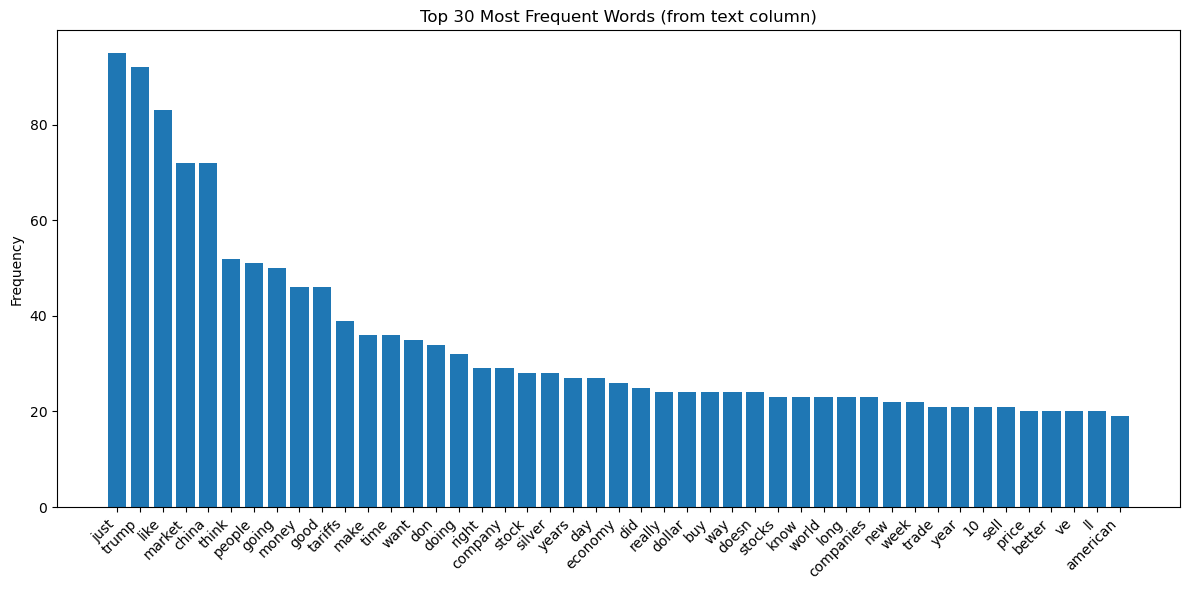

In [36]:
# --- Top 30 words bar chart ---
top_df = freq_df.head(45)
plt.figure(figsize=(12, 6))
plt.bar(top_df["word"], top_df["count"])
plt.xticks(rotation=45, ha="right")
plt.title("Top 30 Most Frequent Words (from text column)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

In [37]:
# --- Rank–frequency plots ---
y = freq_df["count"].values
x = range(1, len(y) + 1)

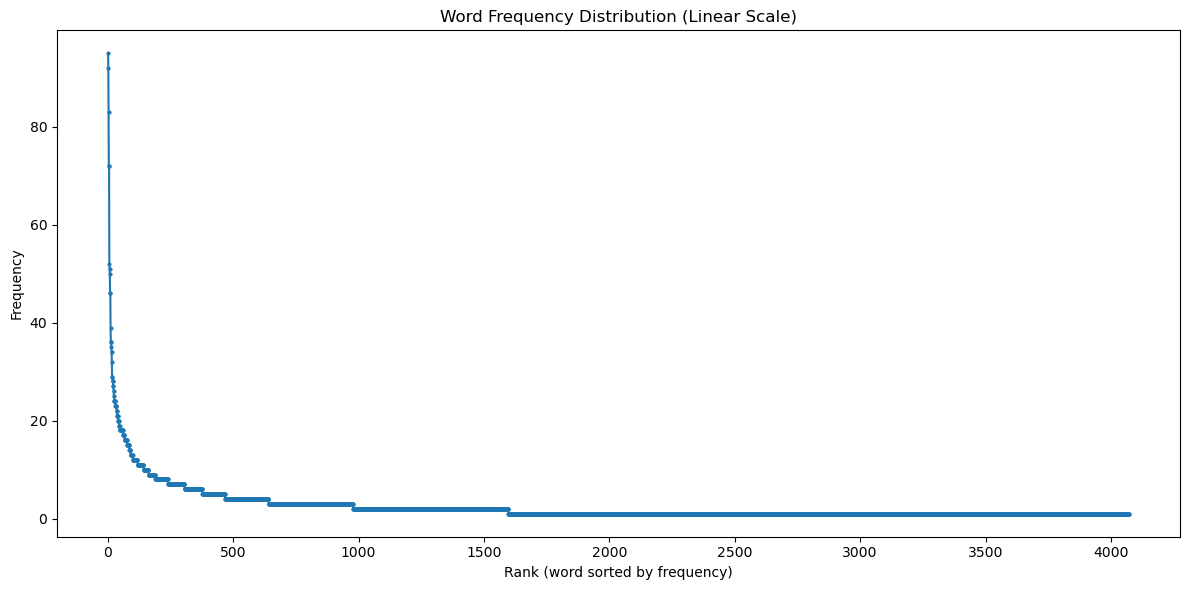

In [38]:
# Linear scale
plt.figure(figsize=(12, 6))
plt.plot(x, y, marker="o", linestyle="-", markersize=2)
plt.title("Word Frequency Distribution (Linear Scale)")
plt.xlabel("Rank (word sorted by frequency)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

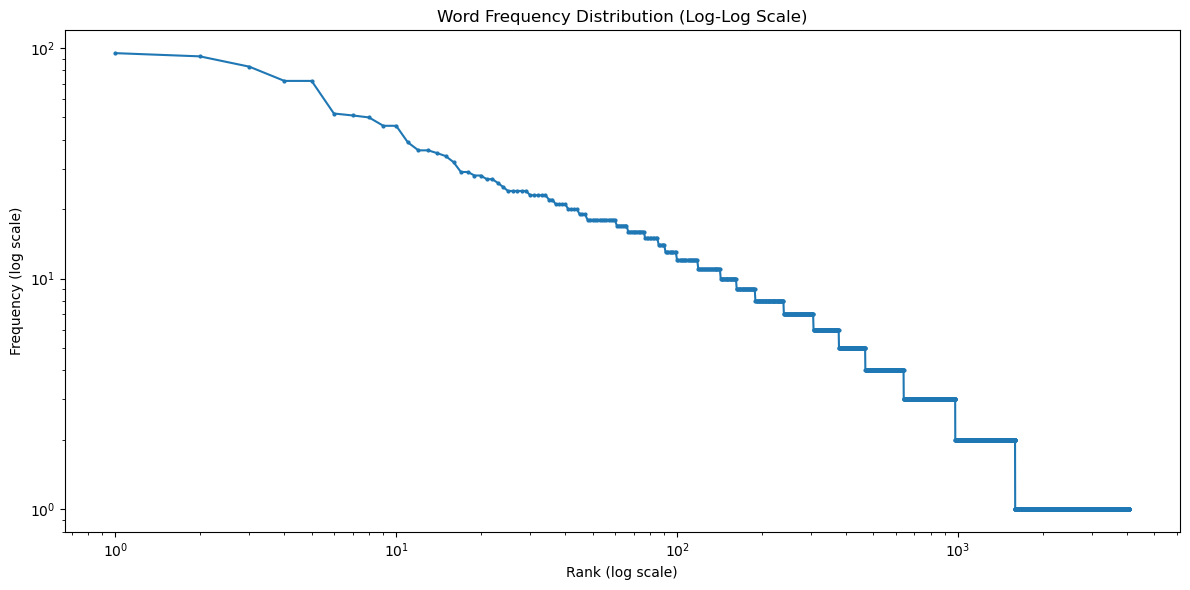

In [39]:
# Log–log scale
plt.figure(figsize=(12, 6))
plt.loglog(x, y, marker="o", linestyle="-", markersize=2)
plt.title("Word Frequency Distribution (Log-Log Scale)")
plt.xlabel("Rank (log scale)")
plt.ylabel("Frequency (log scale)")
plt.tight_layout()
plt.show()


### Here Below are a few different meaningful new data visualizations

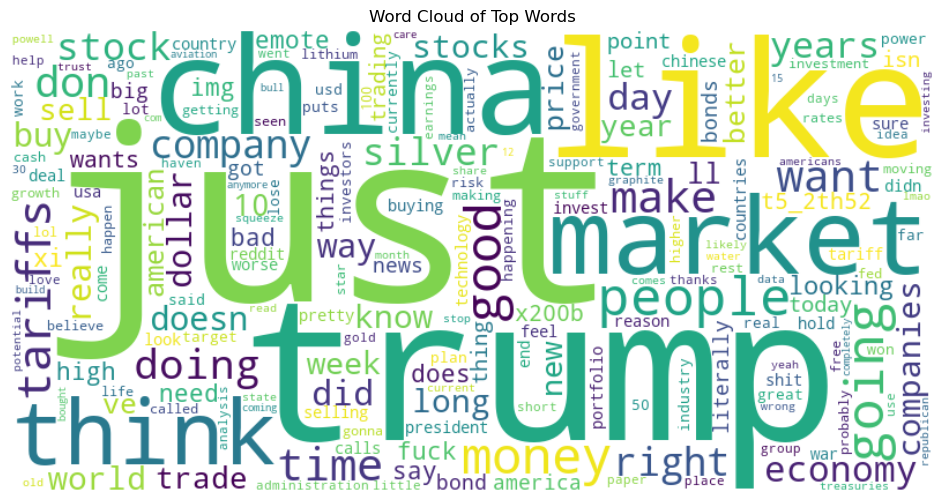

In [40]:
word_freq = dict(zip(vocab, counts))

# Generate word cloud
wc = WordCloud(width=800, height=400,
               background_color="white",
               colormap="viridis",
               max_words=200).generate_from_frequencies(word_freq)

# Plot
plt.figure(figsize=(12,6))
plt.imshow(wc, interpolation="bilinear")
plt.axis("off")
plt.title("Word Cloud of Top Words")
plt.show()

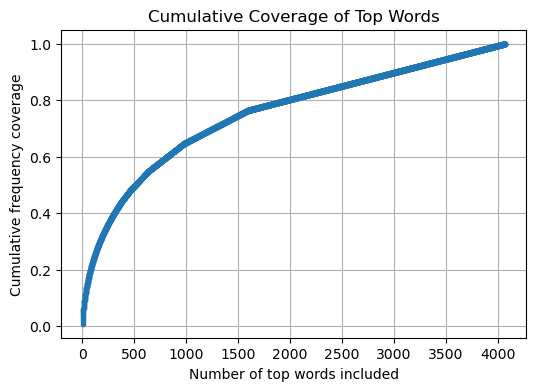

In [41]:
# Sort word counts in descending order
sorted_counts = np.sort(counts)[::-1]

# Ranks for each word (1, 2, 3, …)
ranks = np.arange(1, len(sorted_counts)+1)

# Cumulative frequency (normalized)
cum_freq = np.cumsum(sorted_counts) / np.sum(sorted_counts)

# Plot
plt.figure(figsize=(6,4))
plt.plot(ranks, cum_freq, marker=".")
plt.xlabel("Number of top words included")
plt.ylabel("Cumulative frequency coverage")
plt.title("Cumulative Coverage of Top Words")
plt.grid(True)
plt.show()

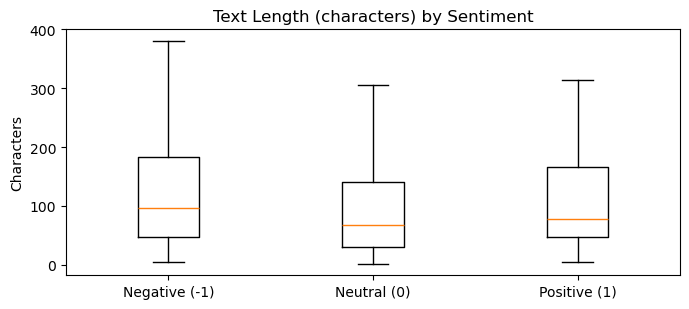

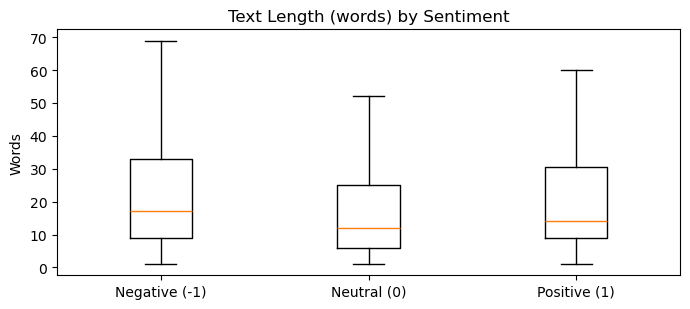

In [42]:
X_len = X[['text','label']].dropna().copy()
X_len['len_chars'] = X_len['text'].astype(str).str.len()
X_len['len_words'] = X_len['text'].astype(str).str.split().str.len()

# Boxplot by label (characters)
plt.figure(figsize=(7,3.2))
data = [X_len.loc[X_len['label']==k, 'len_chars'] for k in [-1.0, 0.0, 1.0]]
plt.boxplot(data, tick_labels=["Negative (-1)", "Neutral (0)", "Positive (1)"], showfliers=False)
plt.title("Text Length (characters) by Sentiment")
plt.ylabel("Characters")
plt.tight_layout()
plt.show()

# Boxplot by label (words)
plt.figure(figsize=(7,3.2))
data_w = [X_len.loc[X_len['label']==k, 'len_words'] for k in [-1.0, 0.0, 1.0]]
plt.boxplot(data_w, tick_labels=["Negative (-1)", "Neutral (0)", "Positive (1)"], showfliers=False)
plt.title("Text Length (words) by Sentiment")
plt.ylabel("Words")
plt.tight_layout()
plt.show()

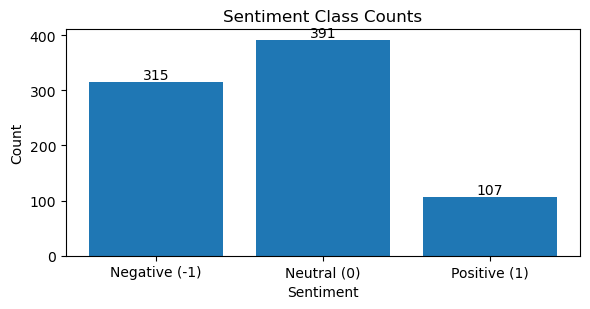

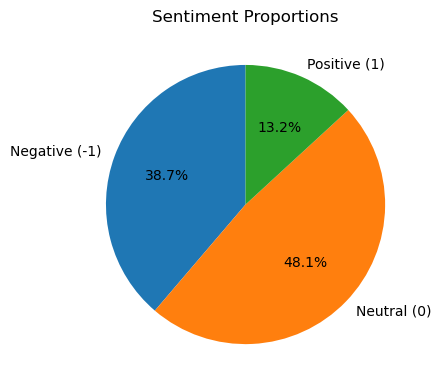

In [43]:
#Class balance (counts & proportions)
labels = X['label'].astype(float)  # ensure numeric -1,0,1
counts = labels.value_counts().sort_index()  # order: -1, 0, 1
order = [-1.0, 0.0, 1.0]
names = { -1.0: "Negative (-1)", 0.0: "Neutral (0)", 1.0: "Positive (1)" }
vals = [counts.get(i, 0) for i in order]

plt.figure(figsize=(6,3.2))
plt.bar([names[i] for i in order], vals)
plt.title("Sentiment Class Counts")
plt.xlabel("Sentiment")
plt.ylabel("Count")
for i,v in enumerate(vals):
    plt.text(i, v, str(v), ha="center", va="bottom", fontsize=10)
plt.tight_layout()
plt.show()

plt.figure(figsize=(4.5,4.5))
plt.pie(vals, labels=[names[i] for i in order], autopct="%.1f%%", startangle=90)
plt.title("Sentiment Proportions")
plt.tight_layout()
plt.show()

# Phase 2